### Analysing Marketing Campaigns Data

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

### Que1. see data

In [3]:
df=pd.read_csv('../../Data_Files/Project_sample_Data/marketing_data.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP


### Que2. Types of columns

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4    Income              2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

# 📊 Advertising Dataset – EDA Interview & Real-World Scenario Questions

Below are structured questions based on the provided dataset.
Questions are divided into **Easy**, **Intermediate**, and **Advanced** levels.

---

# ⭐ Easy-Level Questions (Basic Understanding)

1. What is the distribution of `Income` across customers?
2. Which age group (derived from `Year_Birth`) is the largest?
3. How many customers have kids (`Kidhome`) vs teens (`Teenhome`)?
4. What is the average amount spent on Wines (`MntWines`)?
5. Which product category has the highest total spending?
6. What percentage of customers accepted each campaign (`AcceptedCmp1–5`)?
7. How many customers complained (`Complain = 1`)?
8. What is the average `Recency` value? What does it represent?
9. Which channel shows the highest purchases: Web, Store, or Catalog?
10. What is the average number of web visits (`NumWebVisitsMonth`)?
---

---

# ⭐ Intermediate-Level Questions (Data Relationships)

1. Does income affect total spending (sum of all `Mnt*` columns)?
2. Is Recency negatively correlated with purchases?
3. Does marital status or education influence customer spending?
4. Which age group is most likely to respond to campaigns?
5. Is there a relationship between website visits and web purchases?
6. Do customers with children spend less on luxury products (like Gold)?
7. Are catalog buyers significantly older than web buyers?
8. Do high-income customers accept more campaigns?
9. Which product category is most correlated with total purchases?
10. How does customer country affect buying behavior?

---

---

# ⭐ Advanced / Real-World Business & ML Questions

1. Identify customer segments using clustering — what segment definitions emerge?
2. Which factors most strongly predict campaign acceptance?
3. Build a predictive model: Can we predict `Response` based on spending behavior?
4. Perform RFM Analysis — which segments are best/worst?
5. What characteristics define high-value customers (top 10%)?
6. Is there evidence of seasonality or cohort patterns based on `Dt_Customer`?
7. Build a churn prediction model using Recency and purchasing behavior.
8. Identify cross-selling opportunities between product categories.
9. Can we build an LTV (Customer Lifetime Value) model from this dataset?
10. Using hypothesis testing, do customers with kids spend significantly less?

---

---

# ⭐ Domain + Real Interview Scenarios

1. The marketing budget is limited — which campaign should be prioritized?
2. How to reduce churn based on Recency and Web Visits?
3. How will you create customer personas from the dataset?
4. What insights can the company use to launch new product bundles?
5. How do social/demographic factors affect purchase probability?
6. How can the company personalize ads for high-value customers?
7. What strategy would maximize wine sales?
8. How would you detect outlier customers and why is it important?
9. What two features would you recommend for segmenting customers?
10. If the CEO wants to increase acceptance rates, what 3 data-driven steps will you take?

---

### Ques is their any missing data

In [5]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
 Income                24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64

### Which columns are numerical and which are categorical

In [25]:
df.select_dtypes('number').columns

Index(['ID', 'Year_Birth', ' Income ', 'Kidhome', 'Teenhome', 'Recency',
       'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
       'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
       'AcceptedCmp1', 'AcceptedCmp2', 'Response', 'Complain'],
      dtype='object')

In [35]:
df['Recency'].value_counts(ascending=True).index

Index([44,  7, 22, 59, 41, 58,  5, 15, 69, 88, 66, 35, 79, 33, 45, 75, 99, 85,
       70, 36, 31, 91, 67, 76, 62, 39, 14, 47, 95, 18, 42, 55, 89, 97, 73, 90,
       43, 53, 17, 32, 16, 26, 20, 21,  6, 61, 93, 98, 52, 82, 60, 50, 83, 34,
       28, 63, 84, 64,  1, 12,  9, 37, 57, 38, 96, 19, 25,  8, 40, 77, 68, 11,
       10, 74, 94, 78, 86, 27,  4, 13, 72, 81, 87, 80, 51, 23,  0,  2, 24, 48,
        3, 71, 29, 49, 92, 65, 46, 30, 54, 56],
      dtype='int64', name='Recency')

In [27]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,57091.0,0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,32474.0,1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,21474.0,1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [26]:
df.select_dtypes(['category','object']).columns

Index(['Education', 'Marital_Status', 'Dt_Customer', 'Country'], dtype='object')

In [8]:
df[' Income '].isna().sum()

np.int64(24)

Here income is in Object- we need to convert it into float64

In [9]:
df[' Income ']= df[' Income '].str.strip().str.replace('$','', regex=False).str.replace(',','', regex=False).pipe(pd.to_numeric, errors='coerce')

(array([1.654e+03, 5.540e+02, 7.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([  1730. ,  68223.6, 134717.2, 201210.8, 267704.4, 334198. ,
        400691.6, 467185.2, 533678.8, 600172.4, 666666. ]),
 <BarContainer object of 10 artists>)

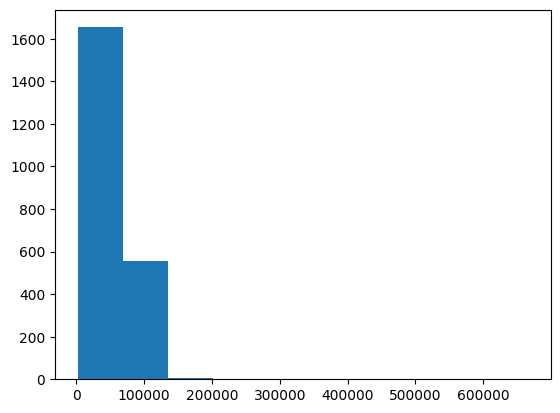

In [10]:
# it has outlier
plt.hist(df[' Income '])

In [11]:
df[' Income '].dtype

dtype('float64')

In [12]:
df[' Income '].max

<bound method Series.max of 0       84835.0
1       57091.0
2       67267.0
3       32474.0
4       21474.0
         ...   
2235    66476.0
2236    31056.0
2237    46310.0
2238    65819.0
2239    94871.0
Name:  Income , Length: 2240, dtype: float64>

check the range of income

(array([ 242.,  818., 1143.,    5.,    0.,    7.,    0.]),
 array([     0.,  25000.,  50000., 100000., 125000., 150000., 175000.,
        200000.]),
 <BarContainer object of 7 artists>)

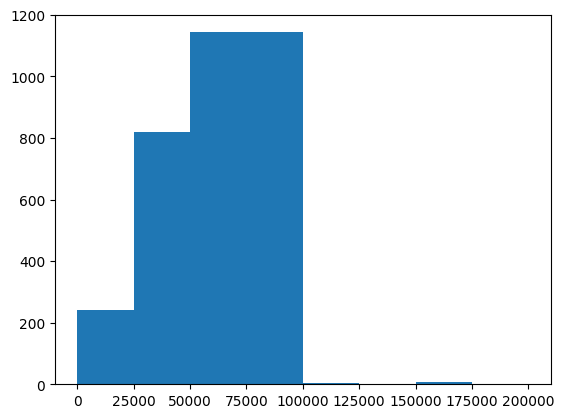

In [13]:
plt.hist(df[' Income '],bins=[0,25000,50000, 100000,125000,150000,175000,200000]) 

Fill the missing income data based on the Education mean

First we calculate mean and median of Income based on the Education by grouping data based on Educations 

In [36]:
df.groupby('Education')[' Income '].mean()

Education
2n Cycle      47612.224631
Basic         20309.192593
Graduation    52089.320763
Master        52699.467027
PhD           55557.597119
Name:  Income , dtype: float64

In [37]:
df.groupby('Education')[' Income '].median()

Education
2n Cycle      46805.0
Basic         20744.0
Graduation    52028.5
Master        50943.0
PhD           55212.0
Name:  Income , dtype: float64

After plotting scatter plot plt.scatter(df['Year_Birth'],df[' Income ']) we found Income has outlier 

In [38]:
# outlier detection by removing edge cases 0.01 and 0.99 
q1= df[' Income '].quantile(0.01)
q99= df[' Income '].quantile(0.99)

df[' Income ']= df[' Income '].clip(lower=q1, upper=q99)

In [39]:
df.groupby('Education')[' Income '].mean()

Education
2n Cycle      47615.529833
Basic         20315.675259
Graduation    52090.744419
Master        52700.176616
PhD           55558.557514
Name:  Income , dtype: float64

In [40]:
df.groupby('Education')[' Income '].median()

Education
2n Cycle      46805.0
Basic         20744.0
Graduation    52028.5
Master        50943.0
PhD           55212.0
Name:  Income , dtype: float64

Fill all missing values based after removing outlier

In [41]:
df[' Income '] = df.groupby('Education')[' Income '].transform(lambda x : x.fillna(x.median()))

In [43]:
df[' Income '].isna().sum()

np.int64(0)

show relation between Income and Year_Birth

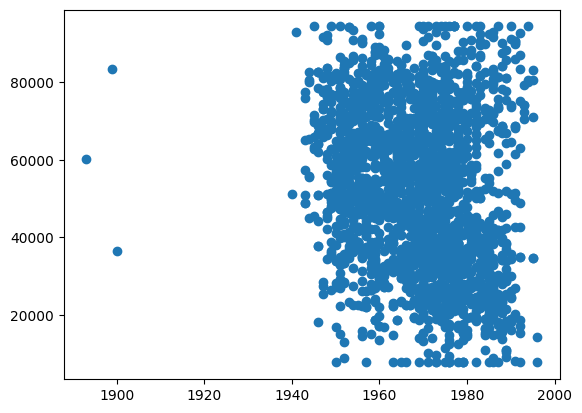

In [44]:
plt.scatter(df['Year_Birth'],df[' Income '])

(array([ 70., 173., 255., 318., 288., 288., 291., 260., 211.,  86.]),
 array([ 7754.232 , 16421.7716, 25089.3112, 33756.8508, 42424.3904,
        51091.93  , 59759.4696, 68427.0092, 77094.5488, 85762.0884,
        94429.628 ]),
 <BarContainer object of 10 artists>)

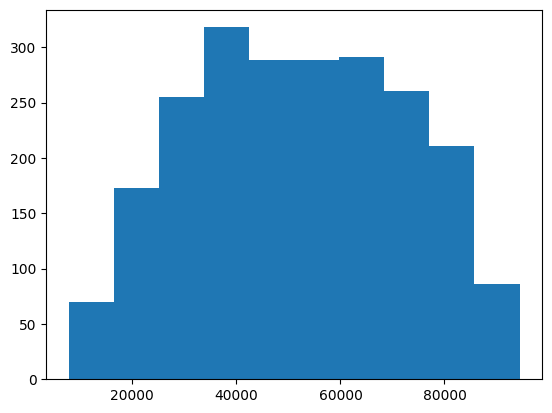

In [45]:
plt.hist(df[' Income '])

QUes : Show how many people are in diff education

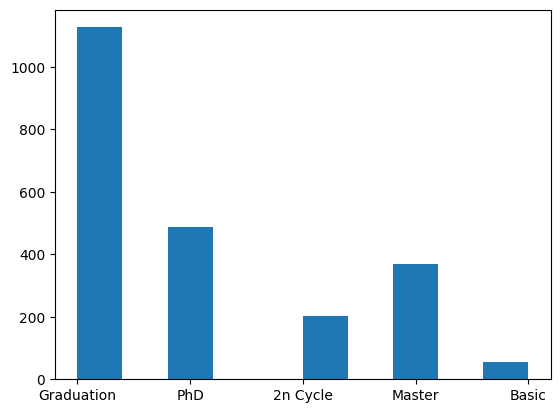

In [23]:
plt.hist(df['Education'])

plt.show()

In [136]:
df['Education'].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

Ques : Is their any relation in Education and Income

In [24]:
df['Country'].value_counts()

Country
SP     1095
SA      337
CA      268
AUS     160
IND     148
GER     120
US      109
ME        3
Name: count, dtype: int64

## GROUP 3 — EASY / FUNDAMENTAL QUESTIONS (LOWER CRITICALITY, GOOD FOR BASICS)

### A. Basic Summary & Exploration

51.	What is the distribution of income? = How does the Income column look in terms of range, shape, and pattern?
52.	What is the average amount spent on Wines?
53.	How many customers accepted each campaign?
54.	How many customers complained?
55.	What is the average web visits per month?
56.	What is the average Recency?
57.	Which product has the lowest spending?
58.	What is the distribution of total purchases via Web?
59.	How many customers have kids vs teens?
60.	What are the top 10 customers with highest total spending?


In [ ]:
df= pd.read_csv('../../Data_Files/Project_sample_Data/marketing_data.csv')
pd.info()

### 51.	👉 What is the distribution of income

In [ ]:
# 51. What is the distribution of income
    # 👉 “How does the Income column look in terms of range, shape, and pattern?”
    # In other words, it wants you to check: 
        # Are most customers low-income?
        # Are they medium-income? 
        # Are there very high-income customers? 
        # Is the income spread evenly or is it skewed? 
        # Does the dataset contain outliers (e.g., extremely high incomes)? 
        # What is the minimum, maximum, average income? 
        # Does the distribution look normal, left-skewed, or right-skewed?

{'whiskers': [<matplotlib.lines.Line2D at 0x1389a484050>,
 'caps': [<matplotlib.lines.Line2D at 0x1389a4842d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1389a18fed0>],
 'medians': [<matplotlib.lines.Line2D at 0x1389a484550>],
 'fliers': [<matplotlib.lines.Line2D at 0x1389a484690>],
 'means': []}

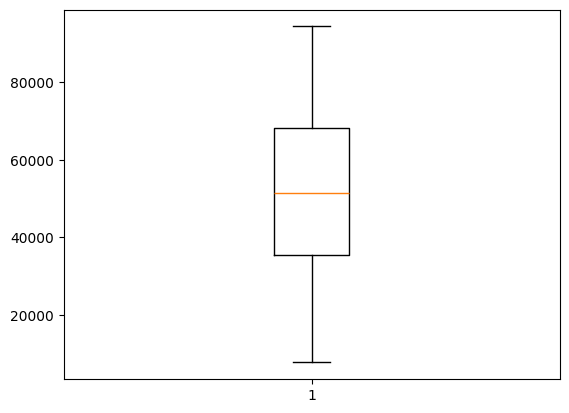

In [55]:
plt.boxplot(x=df[' Income '])